# Hospital Readmission Rates Analysis

## Project Objective
The goal of this project is to review and analyze CMS hospital readmission data. From this analysis, we aim to identify any existing patterns in excess readmission ratio across clinical measures and states. This project focuses on exploratory data analysis, finding existing readmission patterns, and gaining insights for monitoring hospital outcomes.

In [226]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [227]:
# Load the dataset
df = pd.read_csv("../data/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv")
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [228]:
# Explore the dataset
print(f"df.shape: {df.shape}")
print(f"df.columns: {df.columns}")

df.shape: (18330, 12)
df.columns: Index(['Facility Name', 'Facility ID', 'State', 'Measure Name',
       'Number of Discharges', 'Footnote', 'Excess Readmission Ratio',
       'Predicted Readmission Rate', 'Expected Readmission Rate',
       'Number of Readmissions', 'Start Date', 'End Date'],
      dtype='object')


## Data Cleaning
The dataset was cleaned by standardizing column names, converting necessary readmission related columns into numeric format, and removing records without usable readmission rates metrics.

In [229]:
# Check for missing values from the original DataFrame
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Facility Name                     0
Facility ID                       0
State                             0
Measure Name                      0
Number of Discharges          10088
Footnote                      11343
Excess Readmission Ratio       6610
Predicted Readmission Rate     6610
Expected Readmission Rate      6610
Number of Readmissions         6610
Start Date                        0
End Date                          0
dtype: int64


In [230]:
# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
print(f"Cleaned columns: {df.columns}")

Cleaned columns: Index(['facility_name', 'facility_id', 'state', 'measure_name',
       'number_of_discharges', 'footnote', 'excess_readmission_ratio',
       'predicted_readmission_rate', 'expected_readmission_rate',
       'number_of_readmissions', 'start_date', 'end_date'],
      dtype='object')


In [231]:
# Create a copy of the DataFrame for analysis
readmission_df = df.copy()
# Convert relevant columns to numeric, coercing errors to NaN
numeric_cols = [
    "number_of_discharges",
    "excess_readmission_ratio",
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "number_of_readmissions"
]
# Convert columns to numeric, coercing errors to NaN
for col in numeric_cols:
    readmission_df[col] = pd.to_numeric(readmission_df[col], errors="coerce")
# Drop rows with missing values in key numeric columns
readmission_df = readmission_df.dropna(subset=["excess_readmission_ratio", "predicted_readmission_rate", "expected_readmission_rate"])

In [232]:
# Check the shape of the cleaned DataFrame and confirm numeric columns are properly converted
print("readmission_df.shape:", readmission_df.shape)

readmission_df.shape: (11720, 12)


In [233]:
readmission_df.head()


,facility_name,facility_id,state,measure_name,number_of_discharges,footnote,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,number_of_readmissions,start_date,end_date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,NaN,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13.0,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33.0,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19.0,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79.0,07/01/2021,06/30/2024


In [234]:
# Check for missing values in the cleaned DataFrame to ensure we have a complete dataset for analysis
readmission_df.isnull().sum()

facility_name                     0
facility_id                       0
state                             0
measure_name                      0
number_of_discharges           3683
footnote                      11343
excess_readmission_ratio          0
predicted_readmission_rate        0
expected_readmission_rate         0
number_of_readmissions         3683
start_date                        0
end_date                          0
dtype: int64

In [235]:
readmission_df.describe()

,facility_id,number_of_discharges,footnote,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,number_of_readmissions
count,11720.000000,8037.000000,377.0,11720.000000,11720.000000,11720.000000,8037.000000
mean,257135.795904,290.645390,29.0,1.001777,14.981461,14.947978,48.750653
std,158131.646851,270.506342,0.0,0.082050,4.763655,4.620865,49.758206
min,10001.000000,27.000000,29.0,0.469800,1.908000,3.087600,11.000000
25%,110034.000000,122.000000,29.0,0.958200,12.529550,12.623750,19.000000
50%,250004.000000,203.000000,29.0,0.997300,15.860150,15.856550,31.000000
75%,390044.000000,364.000000,29.0,1.042300,18.418500,18.500925,60.000000
max,670309.000000,3672.000000,29.0,1.629700,28.164300,26.865400,847.000000


## Excess Readmission Ratio
The excess readmission ratio compares a hospital's predicted readmission rate with its expected readmission rate. Having an ERR above 1.0 indicates that predicted readmissions were greater than expected.

In [236]:
readmission_df["high_readmission"] = readmission_df["excess_readmission_ratio"] > 1
high_readmission_rate = len(readmission_df[readmission_df["high_readmission"]==True]) / len(readmission_df) * 100
print(f"{high_readmission_rate:.2f}% of hospital measure records have excess readmission ratio above 1.0, indicating higher than expected readmissions.")

48.15% of hospital measure records have excess readmission ratio above 1.0, indicating higher than expected readmissions.


In [237]:
# Analyze the distribution of excess readmission ratios
measure_summary = readmission_df.groupby("measure_name").agg(
    hospital_measure_count=("facility_id", "count"), 
    avg_excess_readmission_ratio=("excess_readmission_ratio", "mean"), 
    avg_predicted_readmission_rate=("predicted_readmission_rate", "mean"), 
    avg_expected_readmission_rate=("expected_readmission_rate", "mean"), 
    high_readmission_rate=("high_readmission", "mean")).reset_index()
measure_summary.sort_values("avg_excess_readmission_ratio", ascending=False)


,measure_name,hospital_measure_count,avg_excess_readmission_ratio,avg_predicted_readmission_rate,avg_expected_readmission_rate,high_readmission_rate
4,READM-30-HIP-KNEE-HRRP,1447,1.003985,5.491330,5.456239,0.478922
1,READM-30-CABG-HRRP,878,1.001789,10.675471,10.650657,0.498861
0,READM-30-AMI-HRRP,1736,1.001755,13.421979,13.384528,0.496544
5,READM-30-PN-HRRP,2715,1.001486,15.597373,15.558561,0.468140
3,READM-30-HF-HRRP,2621,1.001439,19.381564,19.347008,0.489126
2,READM-30-COPD-HRRP,2323,1.001133,18.001379,17.976027,0.472234


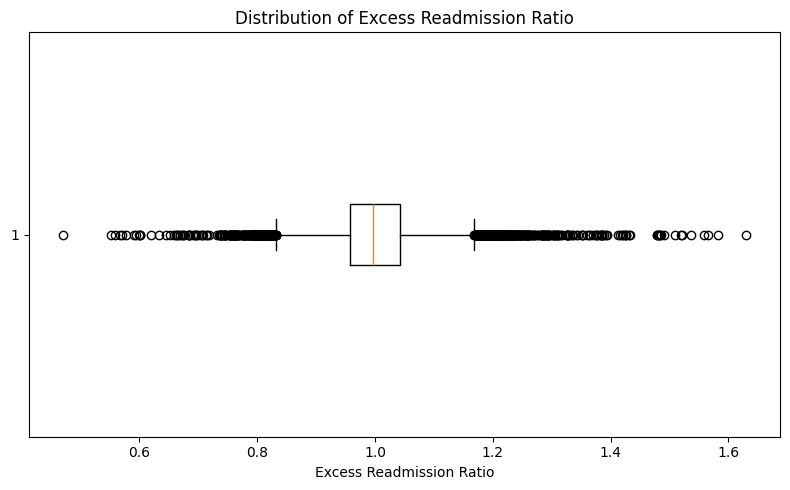

In [244]:
# Visualize the distribution of excess readmission ratios of all hospital measures using a boxplot
plt.figure(figsize=(8, 5))

plt.boxplot(readmission_df["excess_readmission_ratio"], vert = False)

plt.title("Distribution of Excess Readmission Ratio")
plt.xlabel("Excess Readmission Ratio")

plt.tight_layout()
plt.savefig("../outputs/excess_readmission_ratio_distribution.png")
plt.show()


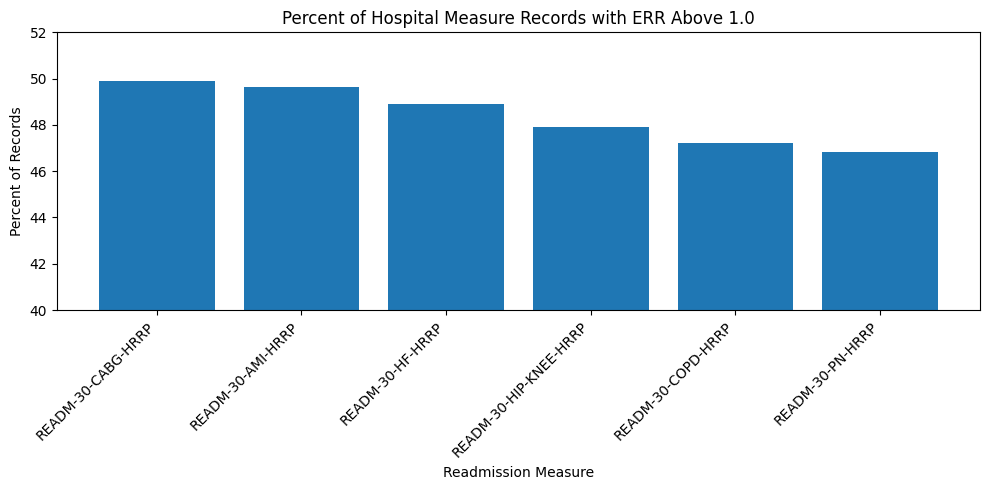

In [245]:
# Visualize the percentage of hospital measure records with excess readmission ratio above 1.0 for each measure
measure_summary_high_rate = measure_summary.sort_values("high_readmission_rate", ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(measure_summary_high_rate["measure_name"], measure_summary_high_rate["high_readmission_rate"] * 100)

plt.title("Percent of Hospital Measure Records with ERR Above 1.0")
plt.xlabel("Readmission Measure")
plt.ylabel("Percent of Records")
plt.xticks(rotation=45, ha="right")
plt.ylim(40, 52)
plt.tight_layout()
plt.savefig("../outputs/high_readmission_rate_by_measure.png")
plt.show()

In [240]:
# Summarize excess readmission ratios and high readmission rates by state

state_summary = readmission_df.groupby("state").agg(
    hospital_measure_count=("facility_id", "count"),
    avg_excess_readmission_ratio=("excess_readmission_ratio", "mean"),
    avg_predicted_readmission_rate=("predicted_readmission_rate", "mean"),
    avg_expected_readmission_rate=("expected_readmission_rate", "mean"),
    high_readmission_rate=("high_readmission", "mean")).reset_index()

state_summary["high_readmission_rate"] = state_summary["high_readmission_rate"] * 100

state_summary.sort_values("high_readmission_rate",ascending=False).head(10)

,state,hospital_measure_count,avg_excess_readmission_ratio,avg_predicted_readmission_rate,avg_expected_readmission_rate,high_readmission_rate
31,NJ,272,1.027668,16.036789,15.615087,65.441176
19,MA,240,1.034428,14.908686,14.383138,62.500000
25,MS,185,1.014094,15.185147,14.945437,61.081081
14,IL,491,1.019390,15.784370,15.529866,57.841141
9,FL,771,1.022866,15.783541,15.467182,57.457847
10,GA,346,1.011403,15.464458,15.308561,55.780347
4,CA,1038,1.010077,15.541372,15.323598,55.202312
17,KY,227,1.010135,16.412252,16.271085,54.185022
49,WV,95,1.011502,15.952066,15.695644,53.684211
34,NY,520,1.001877,15.612862,15.473011,52.692308


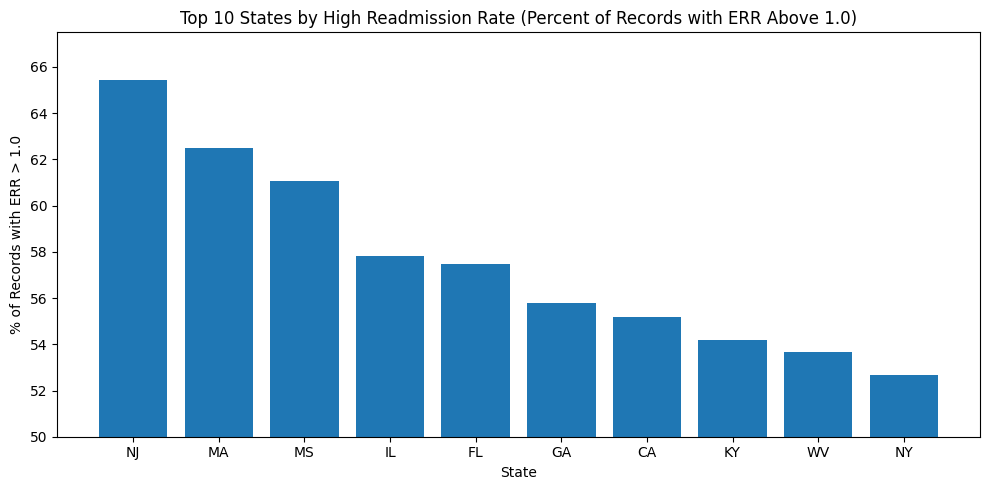

In [246]:
# Visualize the top 10 states by percentage of hospital measure records with excess readmission ratio above 1.0

top_states = state_summary.sort_values("high_readmission_rate", ascending=False).head(10)

plt.figure(figsize=(10, 5))

plt.bar(top_states["state"], top_states["high_readmission_rate"])

plt.title("Top 10 States by High Readmission Rate (Percent of Records with ERR Above 1.0)")
plt.xlabel("State")
plt.ylabel("% of Records with ERR > 1.0")
plt.ylim(50, 67.5)

plt.tight_layout()
plt.savefig("../outputs/high_readmission_rate_by_state.png")
plt.show()

## Analysis Summary

1. 48.15% of hospital measure records had an excess readmission ratio above 1.0, which means that nearly half of the hospital measure records had more readmissions than their expectations of risk adjusted benchmark even after adjusting for patient risk factors.

2. The analyzed results shows that most of the excess readmission ratio values were centered near 1.0. This suggests that overall readmission rates was close to the expectations. However, individual hospital measure records still showed variation.

3. According to the analysis, CABG and AMI are the measures that show the highest proportion of hospital measure records with an excess readmission ratio above 1.0 among all the clinical measures analyzed. These results suggest that hospitals may benefit from monitoring closer to the post discharge care for coronary artery bypass graft surgery and acute myocardial infarction patients.

4. Some states had more than 60% of hospital measure records with excess readmission ratio above 1.0, which indicates there might be significant regional variation in readmission rates.

## Insights and Recommendations

1. I would recommend hospitals to monitor readmission rates of individual measures, instead of only monitoring the at the level of overall hospital. Although most of the average ERR values were close to 1.0, nearly half of the records had ERR above 1.0 at the same time. This analysis results showing that specific measures may still need attention.

2. Improved efforts of prioritizing clinical measures with higher proportion of records above the expected benchmark, such as CABG and AMI, may be needed. 

3. The results indicated state dependent variation, which suggests that regional monitoring can help identify where readmission rates issues are more common. Healthcare organizations could use this type of analysis to prioritize support based on regions and their levels of risks.

## References

Dataset: Centers for Medicare & Medicaid Services. (2026). *Hospital Readmissions Reduction Program*. CMS Provider Data Catalog.  
https://data.cms.gov/provider-data/dataset/9n3s-kdb3
